# BOÖTES III

Boötes III (BoöIII) is a faint, low-surface-brightness stellar system discovered by [Grillmair 2009](https://iopscience.iop.org/article/10.1088/0004-637X/693/2/1118) as a diffuse overdensity within the Styx stream [Carlin and Sand 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aad8c1/meta). Located at a heliocentric distance of $\approx 47$ kpc with an old, metal-poor population, its irregular morphology and spatial coincidence with Styx suggest it is a disrupting dwarf galaxy acting as the stream progenitor. Using $Gaia$ DR2 astrometry and spectroscopy, [Carlin and Sand 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aad8c1/meta) measured a mean proper motion indicating a highly eccentric, retrograde orbit with a close pericentric passage ($\approx 12$ kpc) about $140$ Myr ago. This dynamic alignment, combined with proper motions, reinforces the physical association between BoöIII and Styx. However, membership analysis remains challenging due to field contamination -- notably from the nearby disrupting globular cluster NGC 5466 -- underscoring the need of spectroscopic confirmation.

## Libraries

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astropy.io import ascii, fits
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.io.votable import parse, parse_single_table
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.table import Table, join

from shapely.geometry import Point, Polygon

import csv

import pandas as pd

from scipy.stats import norm, lognorm, expon, gamma

from statistics import mode

import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

import warnings
warnings.filterwarnings('ignore')

import matplotlib.colors as mcolors

## Joint Proper Motions Histograms

In [2]:
def scatter_hist(x, y, x_rr, y_rr, ax, ax_histx, ax_histy, center_pm, err_pm):
    
    ax_histx.tick_params(axis="x", labelbottom=False)
    ax_histy.tick_params(axis="y", labelleft=False)
    
    ax.set_xlim(-20,20)
    ax.set_ylim(-20,20)
    ax.tick_params(labelsize=14)
    ax.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
    ax.set_ylabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
    
    ax.scatter(x, y, marker='o', s=10, label=r'Sources in 6$r_h$', color='lightgrey')
    ax.scatter(x_rr, y_rr, marker='o', edgecolor='k', s=100, label=r'RR Lyrae Variables', color='gold', zorder=2)

    ax_histx.set_ylim(0,1)
    ax_histy.set_xlim(0,1)
    ax_histx.tick_params(labelsize=14)
    ax_histy.tick_params(labelsize=14)
    ax_histx.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histy.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax_histx.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    ax_histy.xaxis.set_major_locator(mticker.MaxNLocator(nbins=3))
    
    ax_histx.hist(x, bins=len(x), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$')
    ax_histy.hist(y, bins=len(y), density=True, color='grey', alpha=0.5, label='Sources in 6$r_h$', orientation='horizontal')
    
    ax_histx.hist(x_rr, bins=len(x_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables')
    ax_histy.hist(y_rr, bins=len(y_rr), density=True, color='gold', alpha=0.8, label='RR Lyrae Variables', orientation='horizontal')
    
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='white', linewidth=5)
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='white', linewidth=5)
    ax_histx.plot([center_pm[0],center_pm[0]], [0,1], c='deepskyblue', linewidth=2, label=r'$\mu_{pmra}$=' + '{:.3f}'.format(center_pm[0]) + '\n' + r'$\sigma_{pmra}$=' + '{:.3f}'.format(err_pm[0]))
    ax_histy.plot([0,1], [center_pm[1],center_pm[1]], c='deepskyblue', linewidth=2, label=r'$\mu_{pmdec}$=' + '{:.3f}'.format(center_pm[1]) + '\n' + r'$\sigma_{pmdec}$=' + '{:.3f}'.format(err_pm[1]))
    
    ax_histx.axvspan(center_pm[0] - 3*err_pm[0], center_pm[0] + 3*err_pm[0], alpha=0.1, color='cyan', zorder=1)
    ax_histy.axhspan(center_pm[1] - 3*err_pm[1], center_pm[1] + 3*err_pm[1], alpha=0.1, color='cyan', zorder=1)
    
    ax_histx.legend(loc=1, fontsize=14, framealpha=0.95)
    ax_histy.legend(loc=1, fontsize=14, framealpha=0.95)

## Wesenheit Relation for RR Lyrae ([Garofalo et al. 2022](https://doi.org/10.1093/mnras/stac735))

In [3]:
## Garofalo et al. 2022, pag. 14

def pw(period, fe, mu0) : # 'period' in log10
    pw_line = - 2.49 * period + 0.14 * fe - 0.88 + mu0

    return pw_line


## Garofalo et al. 2022, pag. 12-13

def wesen(g, bp, rp) :
    w = g - 1.922 * (bp - rp)
    
    return w


## Error Propagation

def wesen_err(g_err, bp_err, rp_err) :
    w_err = g_err + 1.922 * (bp_err + rp_err)
    
    return w_err

## Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
##### NOTE on errors: 
If using "int_g_average" for $G$-band magnitude, we already have "int_g_average_error"; if using "phot_g_mean_mag", we use the flux-derived error ("phot_g_err"). For $G_{BP}$ and $G_{RP}$, we exclusively use "phot_*_mean_mag" as they are more reliable.

In [4]:
def mag_err(flux, flux_err) :
    mag_error = 1.0857 * flux_err / flux
    
    return mag_error

## Data download

In [5]:
data = pd.read_csv('Data/BootesIII_10.csv', header=0)
#cu5

data_rr = pd.read_csv('Data/vari_rrlyrae.csv', header=0, low_memory=False)
#cu7=coordination unit of variables

data_class = pd.read_csv('Data/vari_classifier_result.csv', header=0)

### UFD parameters ([Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0), table 1)

In [6]:
vivas_table = pd.read_csv('Papers_tables/Vivas_table1.csv', header=0)

vivas = vivas_table[vivas_table['galaxy'] == 'BootesIII']

print(vivas)

      galaxy     ra   dec  M_V  distance  fe_h   r_h  epsilon    PA  r_t  \
1  BootesIII  209.3  26.8 -5.8      47.0  -2.1  60.0      0.5  90.0  NaN   

   N_RR  N_RR.1  N_(RR)  N_RR.2 Ref  Ref.1 Ref.2  
1   1.0       7       2       7   2   17.0    22  


### Known RR Lyrae  in [Tau et al. 2024](https://iopscience.iop.org/article/10.3847/1538-3881/ad1509) (table 2)

In [7]:
tau_table = pd.read_csv('Papers_tables/Tau_table2.csv', header=0)

tau = tau_table[tau_table['galaxy'] == 'BootesIII']

tau_complete = tau

print('RR Lyrae in Tau et al. (2024): ' + str(len(tau_complete)))

#tau_complete.to_csv('Output/BootesIII/BootesIII_rr_Tau_complete.csv', index=False)


# Conversion to integers

tau['source_id'] = tau['source_id'].astype(int)

# From Tau, we keep only the 'source_id' column and merge it with the Gaia Archive data.

tau = tau[['source_id']]

#print(tau)


# Merging with vari_classifier

tau = tau.merge(data_class, on='source_id')


# Merging with vari_rrlyrae

tau_rr = tau.merge(data_rr)
print(tau_rr['source_id'])


print('Correspondence with Gaia Variable Classifier: ' + str(len(tau)))
print('Correspondence with Gaia RR Lyrae: ' + str(len(tau_rr)))

# Tau RR Lyrae + those that do not match the Gaia catalogue
# NOTE: These are all of Tau RR Lyrae excluding the one without a Gaia source_id, 
# so the sample includes both vari_rrlyrae and vari_classifier entries

#tau.to_csv('Output/BootesIII/BootesIII_rr_Tau.csv', index=False)

RR Lyrae in Tau et al. (2024): 32
0     1249231099634348544
1     1250883833113992448
2     1252246609057063168
3     1253064405189570816
4     1257024914792212736
5     1257911670920015104
6     1258556500130302080
7     1258709504045092608
8     1259629279881853568
9     1260047442192835968
10    1443201542231710592
11    1443914957775067392
12    1444925782622868992
13    1444976909913197568
14    1447594232919176192
15    1449382103249666432
16    1450165337781635584
17    1450391626723098496
18    1450735121027824000
19    1450750170592551040
20    1450755118394910720
21    1450796178282259072
22    1451041850411971840
23    1452142427191511808
24    1452544990182058752
25    1453431020459339008
26    1456624758140656512
27    1482006163731184256
28    1258096354513939328
29    1456272197161366144
30    1254331626700904064
31    1255773498761714560
Name: source_id, dtype: int64
Correspondence with Gaia Variable Classifier: 32
Correspondence with Gaia RR Lyrae: 32


### Spectroscopic members ([Carlin and Sand 2018](https://iopscience.iop.org/article/10.3847/1538-4357/aad8c1/meta))
- Table1: Horizontal Branch member stars
- Table2: Isochrone-selected member stars

In [8]:
memb_hb = pd.read_csv('Papers_tables/Carlin_Sand_table1_BooIII_crossmatch.csv', header=0)
memb_iso = pd.read_csv('Papers_tables/Carlin_Sand_table2_BooIII_crossmatch.csv', header=0)

memb_hb_complete = memb_hb
memb_iso_complete = memb_iso

memb_complete = memb_hb_complete.merge(memb_iso_complete, how='outer')

print('Spectroscopic Members: ' + str(len(memb_hb_complete)))
print('Spectroscopic Members in Isochrone: ' + str(len(memb_iso_complete)))


## Correspondence with Gaia (gaiadr3.gaia_source)

memb_hb['source_id'] = memb_hb['source_id'].astype(int)

memb_hb = memb_hb.merge(data)

memb_iso['source_id'] = memb_iso['source_id'].astype(int)

memb_iso = memb_iso.merge(data)


## Mask for Sources which are not 'NaN' in proper motions

mask_memb_hb = ((np.isnan(memb_hb['pmra']) == False) & (np.isnan(memb_hb['pmdec']) == False))

memb_hb = memb_hb[mask_memb_hb]

print('Correspondence with Gaia Sources: ' + str(len(memb_hb)))


mask_memb_iso = ((np.isnan(memb_iso['pmra']) == False) & (np.isnan(memb_iso['pmdec']) == False))

memb_iso = memb_iso[mask_memb_iso]

print('Correspondence with Gaia objects (Isochrone): ' + str(len(memb_iso)))



## Correspondence with Gaia RR Lyrae (vari_rrlyrae)

memb_hb_rr = memb_hb.merge(data_rr)

print('Correspondence with Gaia RR Lyrae: ' + str(len(memb_hb_rr)))
print(memb_hb_rr['source_id'])


memb_iso_rr = memb_iso.merge(data_rr)

print('Correspondence with Gaia RR Lyrae (Isochrone): ' + str(len(memb_iso_rr)))
print(memb_iso_rr['source_id'])


## All Spectroscopic Members

memb = memb_hb.merge(memb_iso, how='outer')
memb_rr = memb_hb_rr.merge(memb_iso_rr, how='outer')


#memb_rr.to_csv('Output/BootesIII/BootesIII_memb_rr.csv', index=False)

Spectroscopic Members: 16
Spectroscopic Members in Isochrone: 23
Correspondence with Gaia Sources: 16
Correspondence with Gaia objects (Isochrone): 23
Correspondence with Gaia RR Lyrae: 1
0    1258556500130302080
Name: source_id, dtype: int64
Correspondence with Gaia RR Lyrae (Isochrone): 2
0    1450755118394910720
1    1450750170592551040
Name: source_id, dtype: int64


In [9]:
## Proper Motion of spectroscopic members (in separated tables)

mu_memb_hb_ra, std_memb_hb_ra = norm.fit(memb_hb['pmra'])
mu_memb_hb_dec, std_memb_hb_dec = norm.fit(memb_hb['pmdec'])

print('mu_memb_hb_ra: ', mu_memb_hb_ra, '; std_memb_hb_ra: ', std_memb_hb_ra)
print('mu_memb_hb_dec: ', mu_memb_hb_dec, '; std_memb_hb_dec: ', std_memb_hb_dec)


mu_memb_iso_ra, std_memb_iso_ra = norm.fit(memb_iso['pmra'])
mu_memb_iso_dec, std_memb_iso_dec = norm.fit(memb_iso['pmdec'])

print('mu_memb_iso_ra: ', mu_memb_iso_ra, '; std_memb_iso_ra: ', std_memb_iso_ra)
print('mu_memb_iso_dec: ', mu_memb_iso_dec, '; std_memb_iso_dec: ', std_memb_iso_dec)

mu_memb_hb_ra:  -1.191427555385022 ; std_memb_hb_ra:  0.6473157094428963
mu_memb_hb_dec:  -1.0978777403905307 ; std_memb_hb_dec:  0.5621499482340451
mu_memb_iso_ra:  -1.071867888463275 ; std_memb_iso_ra:  0.8322195035623772
mu_memb_iso_dec:  -1.1209540046856457 ; std_memb_iso_dec:  0.7300585243340468


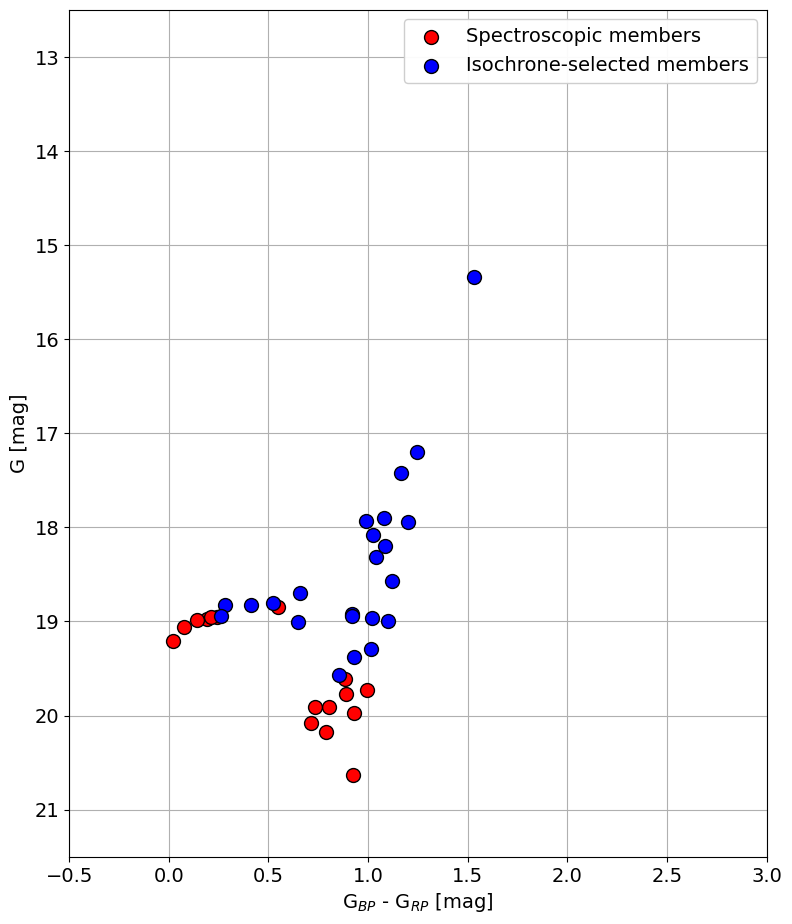

In [10]:
## CMD of spectroscopic members

plt.figure(figsize=(9,11))
plt.xlim(-0.5,3)
plt.ylim(21.5,12.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(memb_hb['phot_bp_mean_mag'] - memb_hb['phot_rp_mean_mag'], memb_hb['phot_g_mean_mag'], s=100, marker='o', c='red', edgecolor='k', label='Spectroscopic members', zorder=2)
plt.scatter(memb_iso['phot_bp_mean_mag'] - memb_iso['phot_rp_mean_mag'], memb_iso['phot_g_mean_mag'], s=100, marker='o', c='blue', edgecolor='k', label='Isochrone-selected members', zorder=2)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_cmd_members.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Geometrical parameters of BootesIII from [Vivas et al. 2020](https://iopscience.iop.org/article/10.3847/1538-4365/ab67c0) (table 1)

In [11]:
center = np.array(object=(float(vivas['ra']), float(vivas['dec'])))
r_half = np.array(object=(float(vivas['r_h'])/60.0)) # 60.00 arcmin


## Mask for Sources with non-Nan pmra, pmdec, phot_g bp rp, int_g bp rp

mask_initial = ((np.isnan(data['pmra']) == False) & (np.isnan(data['pmdec']) == False) &
               (np.isnan(data['phot_g_mean_mag']) == False) & (np.isnan(data['phot_bp_mean_mag']) == False) &
               (np.isnan(data['phot_rp_mean_mag']) == False))

data = data[mask_initial]

print('Sources within 10° (non-Nan values): ' + str(len(data)))



## Mask for Sources within 1*r_h

mask = ((data['ra'] - center[0])**2 + (data['dec'] - center[1])**2) < (1*r_half)**2

data_1rh = data[mask]

print('Sources within 1r_h: ' + str(len(data_1rh)))

Sources within 10° (non-Nan values): 859115
Sources within 1r_h: 7419


### RR Lyrae + Variable star classified ([Gaia DR3](https://doi.org/10.1051/0004-6361/202243940), [Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657))

In [12]:
rr = data_rr.merge(data)
rr_1rh = data_rr.merge(data_1rh)

print('RR Lyrae within 10°: ' + str(len(rr)))
print('RR Lyrae within 1r_h: ' + str(len(rr_1rh)))

#rr.to_csv('Output/BootesIII/BootesIII_rr_10deg.csv', index=False)

RR Lyrae within 10°: 624
RR Lyrae within 1r_h: 11


In [13]:
class_rr = data_class.merge(data)
class_1rh = data_class.merge(data_1rh)

print('Gaia Classified Variables: ' + str(len(class_rr)))
print('Gaia Classified Variables in 1r_h: ' + str(len(class_1rh)))

add_class_rr = class_rr.merge(rr, how='left', indicator=True).query('_merge == "left_only"')

print(str(len(add_class_rr)) + ' additional variables classified by Gaia within 10°:')

print(add_class_rr['source_id'])

#add_class_rr.to_csv('Output/BootesIII/BootesIII_rr_classifier.csv', index=False)

Gaia Classified Variables: 637
Gaia Classified Variables in 1r_h: 11
16 additional variables classified by Gaia within 10°:
27     1244747944051111296
136    1255585069956098560
208    1454784386135767424
252    1454784592293876992
286    1454878188214935552
304    1454784420495578496
335    1454784386135604480
339    1454784656715455360
376    1454784317416167680
407    1454784695372361088
432    1454784317416048000
434    1454784351775804288
439    1454784592294059520
477    1444677469089072640
486    1454784626653820288
523    1454784317416064896
Name: source_id, dtype: int64


### Sagittarius Stream ([Muraveva et al. 2025](https://doi.org/10.1051/0004-6361/202555670), table A3)

In [14]:
datafile_sgr = pd.read_csv('/home/maria-letizia/Scrivania/UFDs_paper/Papers_tables/Muraveva/Muraveva2025_TableA3.csv', header=0)

data_sgr = datafile_sgr[datafile_sgr['source_id'].isin(rr['source_id'])]

print('Sagittarius Stream RR Lyrae Candidates: ' + str(len(data_sgr)))

print(data_sgr['source_id'])


data_sgr_complete = data_sgr

#data_sgr_complete.to_csv('Output/BootesIII/BootesIII_SgrStream_complete.csv', index=False)


data_sgr = data_sgr.drop(columns = ['ra', 'dec', 'pmra', 'pmdec'])

data_sgr = data_sgr.merge(rr)

#data_sgr.to_csv('Output/BootesIII/BootesIII_SgrStream.csv', index=False)


## Remove from my RR Lyrae

print('Initial RR Lyrae: ' + str(len(rr)))

rr = rr[~rr['source_id'].isin(data_sgr['source_id'])]

print('RR Lyrae without those in Sagittarius Stream: ' + str(len(rr)))

Sagittarius Stream RR Lyrae Candidates: 16
912     1239974311239895040
917     1246471939627930240
918     1246901298918620672
920     1248122512739828224
921     1248989889975393280
922     1250883833113992448
923     1251759869003165696
924     1253284071292556544
925     1253558292068974592
926     1254029879478456704
2678    3940648162120975488
4130    1441452975146578560
4131    1443008410438299008
4132    1443201542231710592
4133    1443310600041625600
4134    1444938117768996224
Name: source_id, dtype: int64
Initial RR Lyrae: 624
RR Lyrae without those in Sagittarius Stream: 608


## NGC5272, NGC5466

### RR Lyrae in NGC5272, NGC5466 ([Cruz Reyes et al. 2024](https://doi.org/10.1051/0004-6361/202348961), table 1)

In [15]:
## RRLs after some preliminary cuts
#rr.to_csv('Output/BootesIII/BootesIII_rr_beforeNGC.csv', index=False)


## NGC5272, NGC5466

data_ngc = pd.read_csv('Papers_tables/CruzReyes_table1.csv', header=0)

#print(data_ngc['Cluster'])
data_ngc5272 = data_ngc[data_ngc['Cluster'] == 'NGC_5272_M_3']
data_ngc5466 = data_ngc[data_ngc['Cluster'] == 'NGC_5466']


print('Data from Cruz Reyes et al. 2024:')
print('RR Lyrae in NGC5272: ' + str(len(data_ngc5272)))
print('RR Lyrae in NGC5466: ' + str(len(data_ngc5466)))

data_ngc5272['source_id'] = data_ngc5272['source_id'].astype(int)
data_ngc5466['source_id'] = data_ngc5466['source_id'].astype(int)


## NGC5272 crossmatch with data in vari_rrlyrae e vari_classifier
# Attention: 'data' was cleaned from NaN values on proper motions and 
#   magnitudes, so some stars could miss

data_ngc5272 = data_ngc5272.merge(rr)
data_ngc5272_class = data_ngc5272.merge(class_rr)

data_ngc5272 = data_ngc5272.drop_duplicates(subset=['source_id'])
data_ngc5272_class = data_ngc5272_class.drop_duplicates(subset=['source_id'])

#print(len(data_ngc5272))

print('NGC5272: ')
print('vari_rrlyrae: ' + str(len(data_ngc5272)))
print('vari_classifier: ' + str(len(data_ngc5272_class)))

#print(data_ngc5272)

data_ngc5272_cross = data_ngc5272.merge(data_ngc5272_class, how='inner')
data_ngc5272_extraclass = data_ngc5272_class[~data_ngc5272_class['source_id'].isin(data_ngc5272_cross['source_id'])]

#print(len(data_ngc5272_cross))

print('difference: ' + str(len(data_ngc5272_extraclass)))


## NGC5466 crossmatch with data in vari_rrlyrae e vari_classifier
# Attention: 'data' was cleaned from NaN values on proper motions and 
#   magnitudes, so some stars could miss

data_ngc5466 = data_ngc5466.merge(rr)
data_ngc5466_class = data_ngc5466.merge(class_rr)

data_ngc5466 = data_ngc5466.drop_duplicates(subset=['source_id'])
data_ngc5466_class = data_ngc5466_class.drop_duplicates(subset=['source_id'])

#print(len(data_ngc5466))

print('NGC5466: ')
print('vari_classifier: ' + str(len(data_ngc5466)))
print('vari_classifier: ' + str(len(data_ngc5466_class)))


#data_ngc5272.to_csv('Output/BootesIII/NGC5272_cross_CruzReyes2024.csv', index=False)
#data_ngc5466.to_csv('Output/BootesIII/NGC5466_cross_CruzReyes2024.csv', index=False)


## Remove from my RR Lyrae

print('Initial RR Lyrae: ' + str(len(rr)))

rr = rr[~rr['source_id'].isin(data_ngc5272['source_id'])]
rr = rr[~rr['source_id'].isin(data_ngc5466['source_id'])]

print('RR Lyrae without those in NGC5272, NGC5466: ' + str(len(rr)))

Data from Cruz Reyes et al. 2024:
RR Lyrae in NGC5272: 236
RR Lyrae in NGC5466: 24
NGC5272: 
vari_rrlyrae: 189
vari_classifier: 189
difference: 0
NGC5466: 
vari_classifier: 22
vari_classifier: 22
Initial RR Lyrae: 608
RR Lyrae without those in NGC5272, NGC5466: 397


### Errors on phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag

We do not compute 'phot_*_mean_mag_error' on 'vari_classifier' since we do not compute the Wesenheit magnitude for them

In [16]:
# flux.csv: 'gaiadr3.gaia_source' file (silimar to 'data') with G, BP, RP fluxes

data_flux = pd.read_csv('Data/flux.csv', header=0)


rr = rr.merge(data_flux)

rr['phot_g_mean_mag_error'] = mag_err(rr['phot_g_mean_flux'], rr['phot_g_mean_flux_error'])
rr['phot_bp_mean_mag_error'] = mag_err(rr['phot_bp_mean_flux'], rr['phot_bp_mean_flux_error'])
rr['phot_rp_mean_mag_error'] = mag_err(rr['phot_rp_mean_flux'], rr['phot_rp_mean_flux_error'])


data_sgr = data_sgr.merge(data_flux)

data_sgr['phot_g_mean_mag_error'] = mag_err(data_sgr['phot_g_mean_flux'], data_sgr['phot_g_mean_flux_error'])
data_sgr['phot_bp_mean_mag_error'] = mag_err(data_sgr['phot_bp_mean_flux'], data_sgr['phot_bp_mean_flux_error'])
data_sgr['phot_rp_mean_mag_error'] = mag_err(data_sgr['phot_rp_mean_flux'], data_sgr['phot_rp_mean_flux_error'])


data_ngc5272 = data_ngc5272.merge(data_flux)

data_ngc5272['phot_g_mean_mag_error'] = mag_err(data_ngc5272['phot_g_mean_flux'], data_ngc5272['phot_g_mean_flux_error'])
data_ngc5272['phot_bp_mean_mag_error'] = mag_err(data_ngc5272['phot_bp_mean_flux'], data_ngc5272['phot_bp_mean_flux_error'])
data_ngc5272['phot_rp_mean_mag_error'] = mag_err(data_ngc5272['phot_rp_mean_flux'], data_ngc5272['phot_rp_mean_flux_error'])


data_ngc5466 = data_ngc5466.merge(data_flux)

data_ngc5466['phot_g_mean_mag_error'] = mag_err(data_ngc5466['phot_g_mean_flux'], data_ngc5466['phot_g_mean_flux_error'])
data_ngc5466['phot_bp_mean_mag_error'] = mag_err(data_ngc5466['phot_bp_mean_flux'], data_ngc5466['phot_bp_mean_flux_error'])
data_ngc5466['phot_rp_mean_mag_error'] = mag_err(data_ngc5466['phot_rp_mean_flux'], data_ngc5466['phot_rp_mean_flux_error'])


## Maps

### RA - Dec

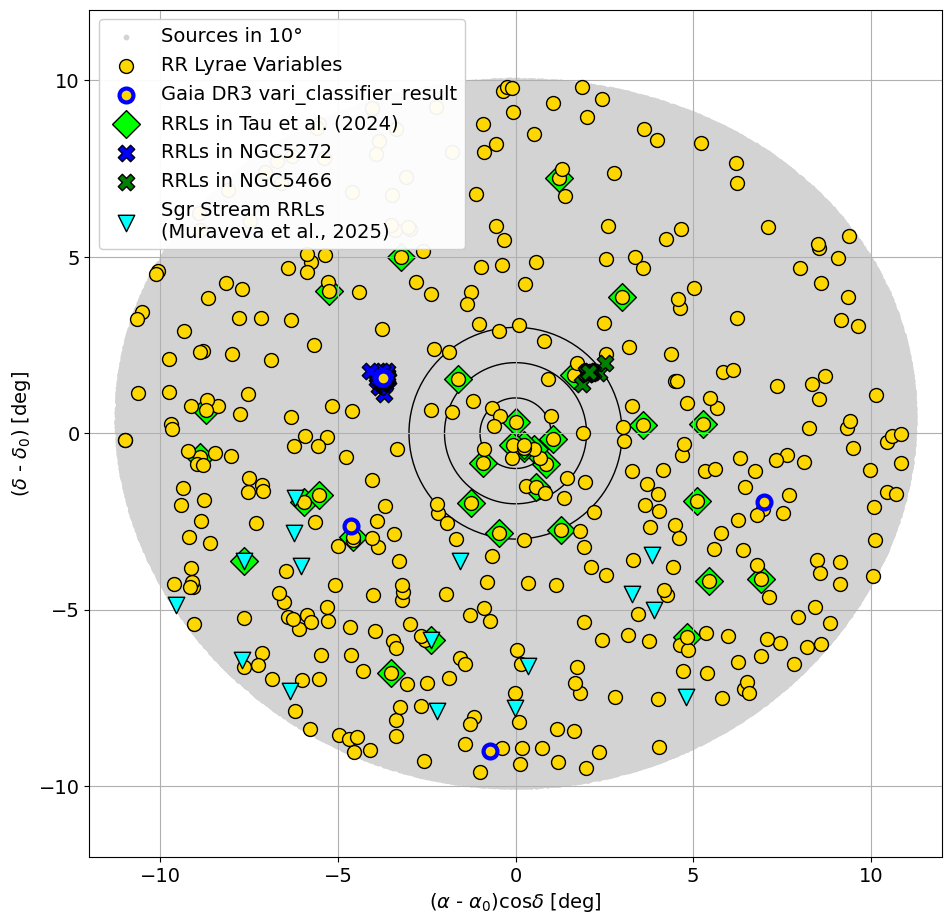

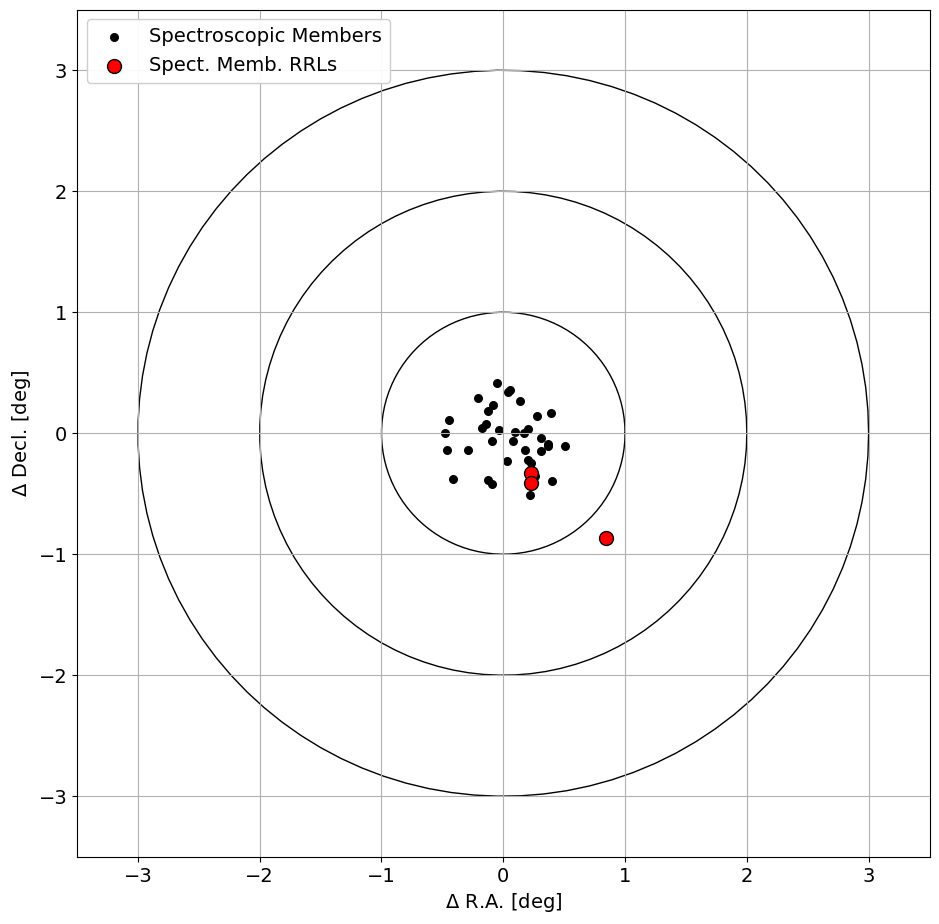

In [17]:
# Map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(11,11))
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'($\alpha$ - $\alpha_0$)cos$\delta$ [deg]', fontsize=14)
plt.ylabel(r'($\delta$ - $\delta_0$) [deg]', fontsize=14)

plt.scatter(data['ra'] - center[0], data['dec'] - center[1], s=10, marker='o', c='lightgrey', label='Sources in 10°', zorder=0)
plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(add_class_rr['ra'] - center[0], add_class_rr['dec'] - center[1], s=100, marker='o', facecolors='gold', edgecolor='blue', linewidth=3, label='Gaia DR3 vari_classifier_result', zorder=3)
plt.scatter(tau['ra'] - center[0], tau['dec'] - center[1], s=200, marker='D', c='lime', edgecolor='k', label='RRLs in Tau et al. (2024)', zorder=1)
plt.scatter(data_ngc5272['ra'] - center[0], data_ngc5272['dec'] - center[1], s=140, marker='X', color='blue', edgecolor='k', label='RRLs in NGC5272', zorder=2)
plt.scatter(data_ngc5466['ra'] - center[0], data_ngc5466['dec'] - center[1], s=140, marker='X', color='green', edgecolor='k', label='RRLs in NGC5466', zorder=2)
plt.scatter(data_sgr['ra'] - center[0], data_sgr['dec'] - center[1], s=140, marker='v', color='cyan', edgecolor='k', label='Sgr Stream RRLs\n(Muraveva et al., 2025)', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_initial_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


# Spectroscopic Members

plt.figure(figsize=(11,11))
plt.xlim(-3.5,3.5)
plt.ylim(-3.5,3.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=30, marker='o', c='black', edgecolor='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_memb_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

### Colormap of RR Lyrae based on 'int_average_g'

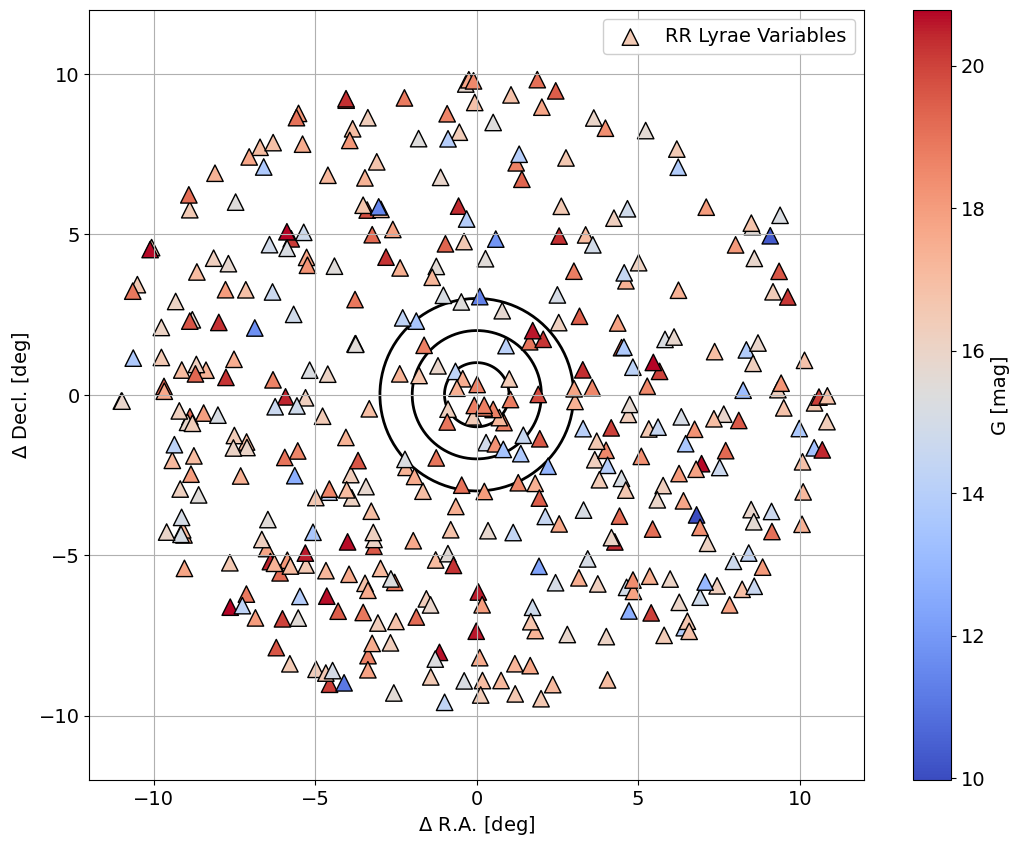

In [18]:
plt.figure(figsize=(12.5,10))
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'$\Delta$ R.A. [deg]', fontsize=14)
plt.ylabel(r'$\Delta$ Decl. [deg]', fontsize=14)

plt.scatter(rr['ra'] - center[0], rr['dec'] - center[1], c=rr['int_average_g'], cmap='coolwarm', s=140, marker='^', edgecolor='k', label='RR Lyrae Variables', zorder=1)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=2, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=2, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=14)
cbar.set_label('G [mag]', fontsize=14)
plt.savefig('Plot/BootesIII/BootesIII_colormap.png', bbox_inches='tight', pad_inches=0)
plt.show()

## RR Lyrae selection through Proper Motions + PWZ

### Proper Motions

#### Errors on Proper Motions ([Gaia EDR3](https://doi.org/10.1051/0004-6361/202039657), table 3): comparison with Spectroscopic Members

In [19]:
# Cut at pm_error = 0.5

print('Initial RR Lyrae: ', len(rr))

mask_pm05 = ((rr['pmra_error'] < 0.5) | (rr['pmdec_error'] < 0.5))
pm05 = rr[mask_pm05]

print('RR Lyrae with pmra_error and pmdec_error < 0.5: ', len(pm05))

if len(pm05) < len(rr) :
    print(str(len(rr) - len(pm05)) + ' RR Lyrae removed:')
    print(rr[~mask_pm05]['source_id'])
    
#rr[~mask_pm05].to_csv('Output/BootesIII/BootesIII_pmerr05.csv', index=False)

Initial RR Lyrae:  397
RR Lyrae with pmra_error and pmdec_error < 0.5:  374
23 RR Lyrae removed:
1      1249494810625709696
3      1253707241534563200
21     1249934129947601920
30     1245138472543380480
85     1246701256524083328
123    1255569127039674624
136    1250234919390441728
159    1259760091700663168
164    1260315546935654272
166    1267055415775186048
167    3939434266924386944
174    1259817021491706368
194    1455777206474739200
213    1448566540500108544
276    1441642847063890048
285    1461997075033087232
329    1443410346361529600
352    1468812294779093632
369    1463442967183376896
373    1441850242441559680
378    1452629274619202816
379    1452836188963917312
381    1454358428453375360
Name: source_id, dtype: int64


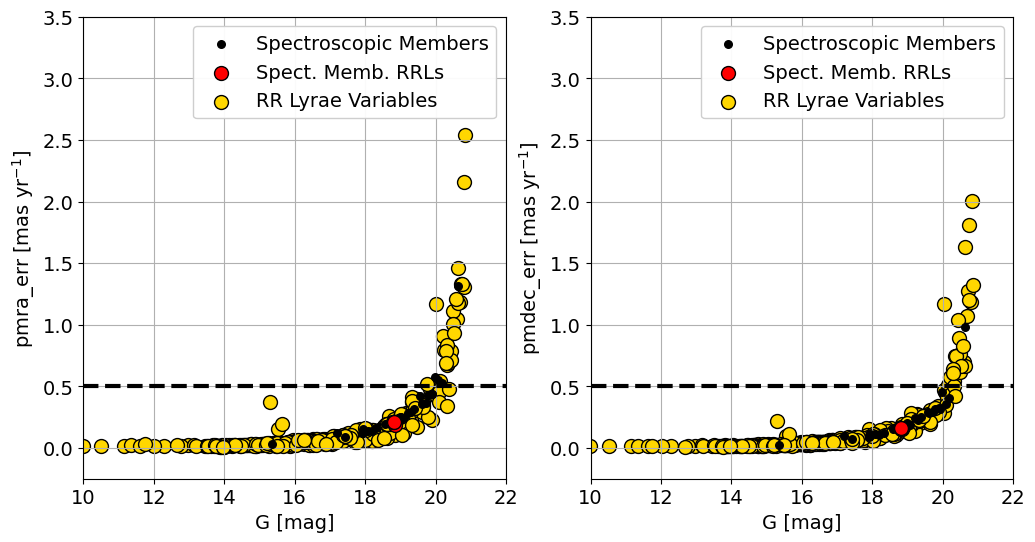

In [20]:
pm1, (pmraerr1, pmdecerr1) = plt.subplots(1, 2, figsize=(12,6))

# PM RA with Spectroscopic Members

pmraerr1.set_xlim(10,22)
pmraerr1.set_ylim(-0.25,3.5)
pmraerr1.tick_params(labelsize=14)
pmraerr1.set_xlabel('G [mag]', fontsize=14)
pmraerr1.set_ylabel(r'pmra_err [mas yr$^{-1}$]', fontsize=14)
pmraerr1.scatter(memb['phot_g_mean_mag'], memb['pmra_error'], s=30, marker='o', color='k', edgecolor='k', label='Spectroscopic Members', zorder=2)
pmraerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmra_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmraerr1.scatter(rr['phot_g_mean_mag'], rr['pmra_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmraerr1.plot([10,22], [0.5,0.5], color='k', linewidth=3, linestyle='dashed')
pmraerr1.legend(loc=1, fontsize=14, framealpha=0.95)
pmraerr1.grid(True)

## PM DEC with Spectroscopic Members

pmdecerr1.set_xlim(10,22)
pmdecerr1.set_ylim(-0.25,3.5)
pmdecerr1.tick_params(labelsize=14)
pmdecerr1.set_xlabel('G [mag]', fontsize=14)
pmdecerr1.set_ylabel(r'pmdec_err [mas yr$^{-1}$]', fontsize=14)
pmdecerr1.scatter(memb['phot_g_mean_mag'], memb['pmdec_error'], s=30, marker='o', color='k', edgecolor='k', label='Spectroscopic Members', zorder=2)
pmdecerr1.scatter(memb_rr['phot_g_mean_mag'], memb_rr['pmdec_error'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=2)
pmdecerr1.scatter(rr['phot_g_mean_mag'], rr['pmdec_error'], s=100, marker='o', color='gold', edgecolor='k', label='RR Lyrae Variables')
pmdecerr1.plot([10,22], [0.5,0.5], color='k', linewidth=3, linestyle='dashed')
pmdecerr1.legend(loc=1, fontsize=14, framealpha=0.95)
pmdecerr1.grid(True)

#plt.savefig('Plot/BootesIII/BootesIII_pm05.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [21]:
# pm_error < 0.5 cut

rr = rr[mask_pm05]

#### Histograms

In [22]:
## Gaussian of Data

mask3 = ((data_1rh['pmra'] > -20) & (data_1rh['pmra'] < 20) & (data_1rh['pmdec'] > -20) & (data_1rh['pmdec'] < 20))
data_mask3 = data_1rh[mask3]

mu_ra, std_ra = norm.fit(data_mask3['pmra'])
mu_dec, std_dec = norm.fit(data_mask3['pmdec'])

x = np.linspace(-50, 50, 1000)
p_ra = norm.pdf(x, mu_ra, std_ra)
p_dec = norm.pdf(x, mu_dec, std_dec)


## Gaussian of RR Lyrae in 3°

mu_rr_ra, std_rr_ra = norm.fit(rr['pmra'])
mu_rr_dec, std_rr_dec = norm.fit(rr['pmdec'])

x_rr = np.linspace(-50, 50, 1000)
p_rr_ra = norm.pdf(x_rr, mu_rr_ra, std_rr_ra)
p_rr_dec = norm.pdf(x_rr, mu_rr_dec, std_rr_dec)


## Gaussian of Sectroscopic Members

mask_m = ((memb['pmra'] > -10) & (memb['pmra'] < 10) & (memb['pmdec'] > -10) & (memb['pmdec'] < 10))
memb_mask = memb[mask_m]

mu_memb_ra, std_memb_ra = norm.fit(memb_mask['pmra'])
mu_memb_dec, std_memb_dec = norm.fit(memb_mask['pmdec'])

x_memb = np.linspace(-20, 20, 1000)
p_memb_ra = norm.pdf(x_memb, mu_memb_ra, std_memb_ra)
p_memb_dec = norm.pdf(x_memb, mu_memb_dec, std_memb_dec)


## Proper Motion centers

center_mymemb = np.array(object=(mu_memb_ra, mu_memb_dec))
err_mymemb = np.array(object=(std_memb_ra, std_memb_dec))

In [23]:
array = {'name': ['sources_ra', 'sources_dec', 'rr_ra', 'rr_dec', 'memb_ra', 'memb_dec'],
         'mu': [mu_ra, mu_dec, mu_rr_ra, mu_rr_dec, mu_memb_ra, mu_memb_dec],
         'std': [std_ra, std_dec, std_rr_ra, std_rr_dec, std_memb_ra, std_memb_dec]}

array_mu_std = pd.DataFrame(array)

print(array_mu_std)

array_mu_std.to_csv('Output/BootesIII/BootesIII_mu_std.csv', index=False)

          name        mu       std
0   sources_ra -4.542351  6.615198
1  sources_dec -4.765383  6.169942
2        rr_ra -2.791467  5.420529
3       rr_dec -3.366231  5.611019
4      memb_ra -1.120918  0.764077
5     memb_dec -1.111487  0.666408


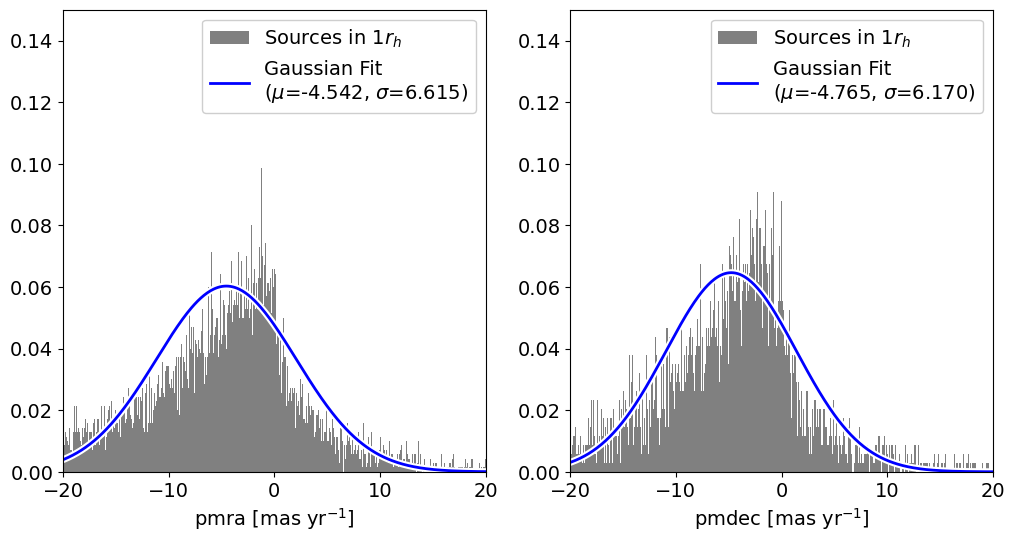

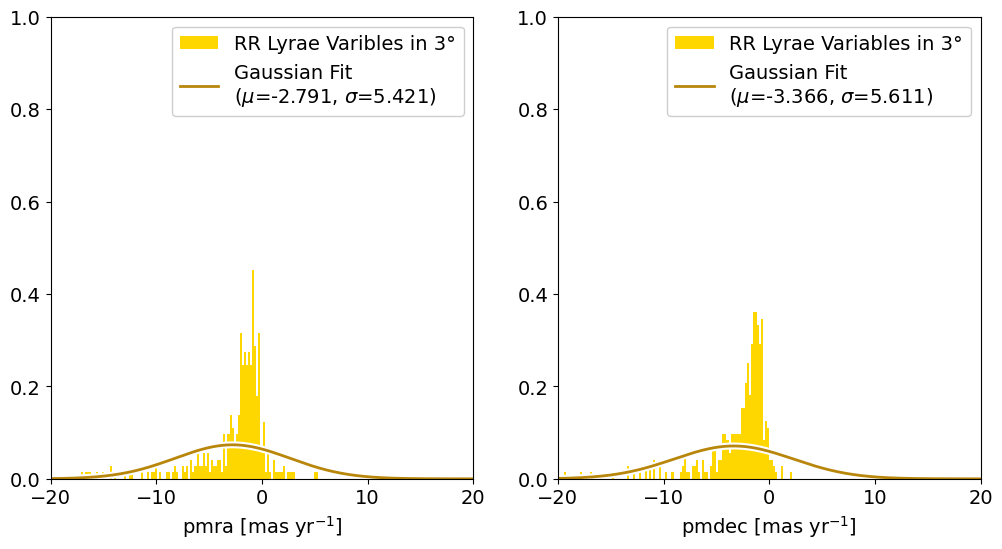

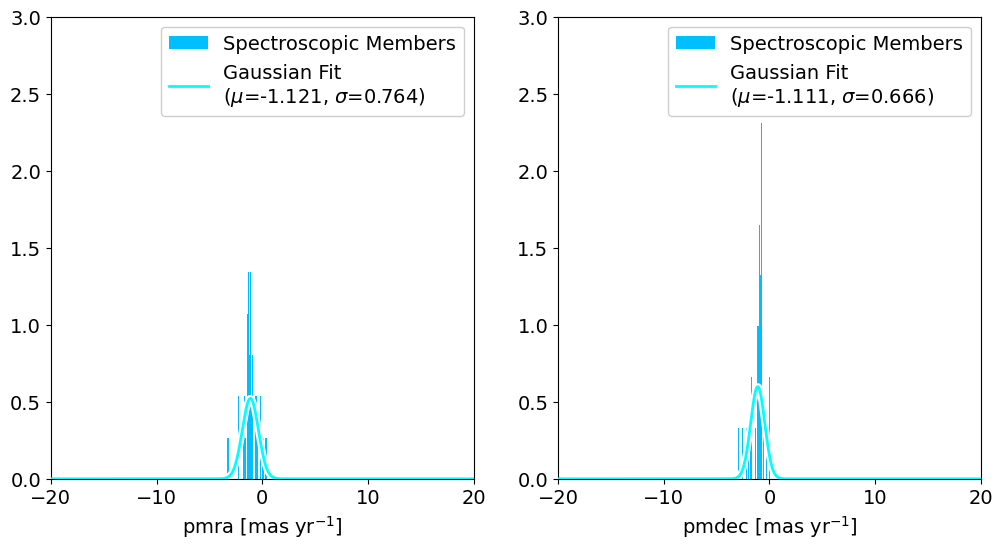

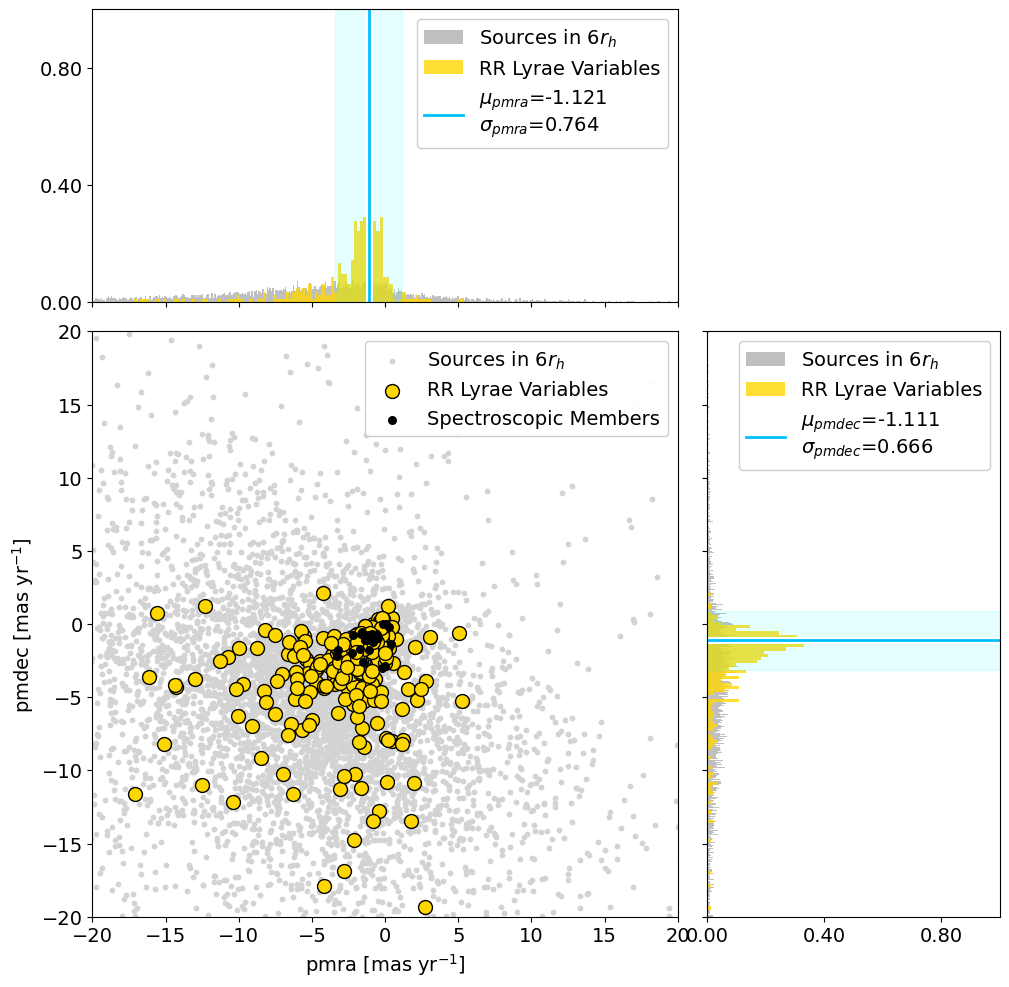

In [24]:
## Histograms

# Sources in 1*r_h

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,0.15)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(data_1rh['pmra'], bins=len(data_1rh), density=True, label=r'Sources in 1$r_h$', color='grey')
pmra1.plot(x, p_ra, c='white', linewidth=5)
pmra1.plot(x, p_ra, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_ra) + ', $\sigma$=' + '{:.3f}'.format(std_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,0.15)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(data_1rh['pmdec'], bins=len(data_1rh), density=True, label=r'Sources in 1$r_h$', color='grey')
pmdec1.plot(x, p_dec, c='white', linewidth=5)
pmdec1.plot(x, p_dec, c='blue', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_dec) + ', $\sigma$=' + '{:.3f}'.format(std_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesIII/BootesIII_pm_sources.png', bbox_inches='tight', pad_inches=0)
plt.show()


# RR Lyrae in 3°

pm1, (pmra1, pmdec1) = plt.subplots(1, 2, figsize=(12,6))

pmra1.set_xlim(-20,20)
pmra1.set_ylim(0,1)
pmra1.tick_params(labelsize=14)
pmra1.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra1.hist(rr['pmra'], bins=len(rr)+50, density=True, label=r'RR Lyrae Varibles in 3°', color='gold')
pmra1.plot(x_rr, p_rr_ra, c='white', linewidth=5)
pmra1.plot(x_rr, p_rr_ra, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_ra) + ', $\sigma$=' + '{:.3f}'.format(std_rr_ra) + ')')
pmra1.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec1.set_xlim(-20,20)
pmdec1.set_ylim(0,1)
pmdec1.tick_params(labelsize=14)
pmdec1.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec1.hist(rr['pmdec'], bins=len(rr)+50, density=True, label=r'RR Lyrae Variables in 3°', color='gold')
pmdec1.plot(x_rr, p_rr_dec, c='white', linewidth=5)
pmdec1.plot(x_rr, p_rr_dec, c='darkgoldenrod', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_rr_dec) + ', $\sigma$=' + '{:.3f}'.format(std_rr_dec) + ')')
pmdec1.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesIII/BootesIII_pm_rr.png', bbox_inches='tight', pad_inches=0)
plt.show()


# With Spectroscopic Members

pm2, (pmra2, pmdec2) = plt.subplots(1, 2, figsize=(12,6))

pmra2.set_xlim(-20,20)
pmra2.set_ylim(0,3)
pmra2.tick_params(labelsize=14)
pmra2.set_xlabel(r'pmra [mas yr$^{-1}$]', fontsize=14)
pmra2.hist(memb['pmra'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmra2.plot(x_memb, p_memb_ra, c='white', linewidth=5)
pmra2.plot(x_memb, p_memb_ra, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_ra) + ', $\sigma$=' + '{:.3f}'.format(std_memb_ra) + ')', zorder=3)
pmra2.legend(loc=1, fontsize=14, framealpha=0.95)

pmdec2.set_xlim(-20,20)
pmdec2.set_ylim(0,3)
pmdec2.tick_params(labelsize=14)
pmdec2.set_xlabel(r'pmdec [mas yr$^{-1}$]', fontsize=14)
pmdec2.hist(memb['pmdec'], bins=len(memb), density=True, label='Spectroscopic Members', color='deepskyblue', zorder=0)
pmdec2.plot(x_memb, p_memb_dec, c='white', linewidth=5)
pmdec2.plot(x_memb, p_memb_dec, c='cyan', linewidth=2, label='Gaussian Fit\n('+r'$\mu$=' + '{:.3f}'.format(mu_memb_dec) + ', $\sigma$=' + '{:.3f}'.format(std_memb_dec) + ')', zorder=3)
pmdec2.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesIII/BootesIII_pm_memb.png', bbox_inches='tight', pad_inches=0)
plt.show()


## Joint Proper Motions

pm3 = plt.figure(layout='tight', figsize=(12,12))
ax3 = pm3.add_subplot()

ax3.set_aspect('equal')

ax3_histx = ax3.inset_axes([0, 1.05, 1, 0.5], sharex=ax3)
ax3_histy = ax3.inset_axes([1.05, 0, 0.5, 1], sharey=ax3)

scatter_hist(data_1rh['pmra'], data_1rh['pmdec'], rr['pmra'], rr['pmdec'], ax3, ax3_histx, ax3_histy, center_mymemb, err_mymemb)

ax3.scatter(memb['pmra'], memb['pmdec'], s=30, color='k', edgecolor='k', label='Spectroscopic Members', zorder=2)

ax3.legend(loc=1, fontsize=14, framealpha=0.95)

plt.savefig('Plot/BootesIII/BootesIII_pm_join.png', bbox_inches='tight', pad_inches=0)
plt.show()

NGC5272
mu_ra:  -0.07843612190009697 ; std_ra:  1.1263473476606556
mu_dec:  -2.694118583631556 ; std_dec:  0.578069750654458
NGC5466
mu_ra:  -5.225015811444505 ; std_ra:  0.3767959073365456
mu_dec:  -0.8870140485713349 ; std_dec:  0.30680598905828443


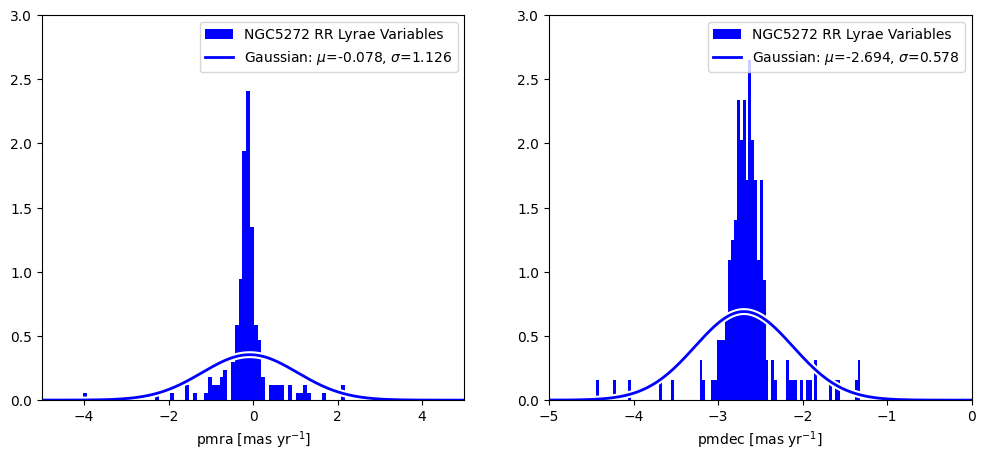

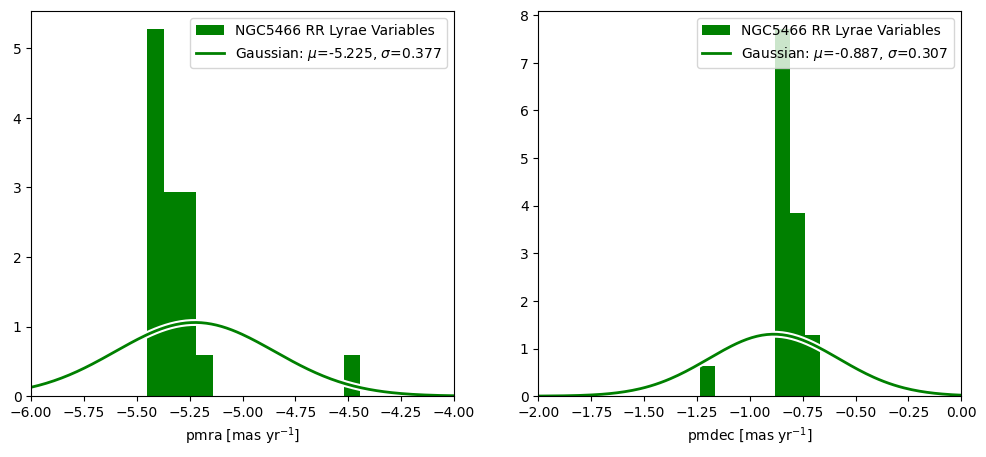

In [25]:
## Proper Motions of NGC5272, NGC5466


## Gaussian of Data

# NGC5272

ngc5272_mu_ra, ngc5272_std_ra = norm.fit(data_ngc5272['pmra'])
ngc5272_mu_dec, ngc5272_std_dec = norm.fit(data_ngc5272['pmdec'])

print('NGC5272')
print('mu_ra: ', ngc5272_mu_ra, '; std_ra: ', ngc5272_std_ra)
print('mu_dec: ', ngc5272_mu_dec, '; std_dec: ', ngc5272_std_dec)

ngc5272_x = np.linspace(-6, 6, 1000)
ngc5272_p_ra = norm.pdf(ngc5272_x, ngc5272_mu_ra, ngc5272_std_ra)
ngc5272_p_dec = norm.pdf(ngc5272_x, ngc5272_mu_dec, ngc5272_std_dec)


#NGC5466

ngc5466_mu_ra, ngc5466_std_ra = norm.fit(data_ngc5466['pmra'])
ngc5466_mu_dec, ngc5466_std_dec = norm.fit(data_ngc5466['pmdec'])

print('NGC5466')
print('mu_ra: ', ngc5466_mu_ra, '; std_ra: ', ngc5466_std_ra)
print('mu_dec: ', ngc5466_mu_dec, '; std_dec: ', ngc5466_std_dec)

ngc5466_x = np.linspace(-6, 6, 1000)
ngc5466_p_ra = norm.pdf(ngc5466_x, ngc5466_mu_ra, ngc5466_std_ra)
ngc5466_p_dec = norm.pdf(ngc5466_x, ngc5466_mu_dec, ngc5466_std_dec)


## Histograms

# NGC5272

pm4, (pmra4, pmdec4) = plt.subplots(1, 2, figsize=(12,5))

pmra4.set_xlim(-5,5)
pmra4.set_ylim(0,3)
pmra4.set_xlabel(r'pmra [mas yr$^{-1}$]')
pmra4.hist(data_ngc5272['pmra'], bins=len(data_ngc5272), density=True, label=r'NGC5272 RR Lyrae Variables', color='blue')
pmra4.plot(ngc5272_x, ngc5272_p_ra, c='white', linewidth=5)
pmra4.plot(ngc5272_x, ngc5272_p_ra, c='blue', linewidth=2, label=r'Gaussian: $\mu$=' + '{:.3f}'.format(ngc5272_mu_ra) + ', $\sigma$=' + '{:.3f}'.format(ngc5272_std_ra))
pmra4.legend()


pmdec4.set_xlim(-5,0)
pmdec4.set_ylim(0,3)
pmdec4.set_xlabel(r'pmdec [mas yr$^{-1}$]')
pmdec4.hist(data_ngc5272['pmdec'], bins=len(data_ngc5272), density=True, label=r'NGC5272 RR Lyrae Variables', color='blue')
pmdec4.plot(ngc5272_x, ngc5272_p_dec, c='white', linewidth=5)
pmdec4.plot(ngc5272_x, ngc5272_p_dec, c='blue', linewidth=2, label=r'Gaussian: $\mu$=' + '{:.3f}'.format(ngc5272_mu_dec) + ', $\sigma$=' + '{:.3f}'.format(ngc5272_std_dec))
pmdec4.legend()

plt.savefig('Plot/BootesIII/BootesIII_pm_ngc5272.png', bbox_inches='tight', pad_inches=0)
plt.show()


# NGC5466

pm5, (pmra5, pmdec5) = plt.subplots(1, 2, figsize=(12,5))#, sharey=True)

pmra5.set_xlim(-6,-4)
pmra5.set_xlabel(r'pmra [mas yr$^{-1}$]')
pmra5.hist(data_ngc5466['pmra'], bins=len(data_ngc5466), density=True, label=r'NGC5466 RR Lyrae Variables', color='green')
pmra5.plot(ngc5466_x, ngc5466_p_ra, c='white', linewidth=5)
pmra5.plot(ngc5466_x, ngc5466_p_ra, c='green', linewidth=2, label=r'Gaussian: $\mu$=' + '{:.3f}'.format(ngc5466_mu_ra) + ', $\sigma$=' + '{:.3f}'.format(ngc5466_std_ra))
pmra5.legend()


pmdec5.set_xlim(-2,0)
pmdec5.set_xlabel(r'pmdec [mas yr$^{-1}$]')
pmdec5.hist(data_ngc5466['pmdec'], bins=len(data_ngc5466), density=True, label=r'NGC5466 RR Lyrae Variables', color='green')
pmdec5.plot(ngc5466_x, ngc5466_p_dec, c='white', linewidth=5)
pmdec5.plot(ngc5466_x, ngc5466_p_dec, c='green', linewidth=2, label=r'Gaussian: $\mu$=' + '{:.3f}'.format(ngc5466_mu_dec) + ', $\sigma$=' + '{:.3f}'.format(ngc5466_std_dec))
pmdec5.legend()

plt.savefig('Plot/BootesIII/BootesIII_pm_ngc5466.png', bbox_inches='tight', pad_inches=0)
plt.show()

### Sources within 3$\sigma$ of mean proper motions (w.r.t. Spectroscopic Members)

In [26]:
## Sources in 10°

mask4 = (data['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_final = data[mask4]

mask4 = (data_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_final = data_final[mask4]

print('Sources within 3sigma of mean proper motions in 10°: ' + str(len(data_final)))


## Sources in 1*r_h

mask4 = (data_1rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_1rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_1rh_final = data_1rh[mask4]

mask4 = (data_1rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_1rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_1rh_final = data_1rh_final[mask4]

print('Sources within 3sigma of mean proper motions in 1r_h: ' + str(len(data_1rh_final)))


## RR Lyrae in 10°

mask5 = (rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_final = rr[mask5]

mask5 = (rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_final = rr_final[mask5]

print('RR Lyrae within 3sigma of mean proper motions in 10°: ' + str(len(rr_final)))


## RR Lyrae in 1*r_h

mask6 = (rr_1rh['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (rr_1rh['pmra'] >= mu_memb_ra - 3*std_memb_ra)

rr_1rh_final = rr_1rh[mask6]

mask6 = (rr_1rh_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (rr_1rh_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

rr_1rh_final = rr_1rh_final[mask6]

print('RR Lyrae within 3sigma of mean proper motions in 1r_h: ' + str(len(rr_1rh_final)))


## RR Lyrae Classified in 10°

mask7 = (add_class_rr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (add_class_rr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

add_class_rr_final = add_class_rr[mask7]

mask7 = (add_class_rr_final['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (add_class_rr_final['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

add_class_rr_final = add_class_rr_final[mask7]

print('Classified RR Lyrae within 3sigma of mean proper motions in 10°: ' + str(len(add_class_rr_final)))

Sources within 3sigma of mean proper motions in 10°: 94315
Sources within 3sigma of mean proper motions in 1r_h: 744
RR Lyrae within 3sigma of mean proper motions in 10°: 222
RR Lyrae within 3sigma of mean proper motions in 1r_h: 9
Classified RR Lyrae within 3sigma of mean proper motions in 10°: 13


In [27]:
print('NGC5272 RR Lyrae: ' + str(len(data_ngc5272)))

mask5_2 = (data_ngc5272['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_ngc5272['pmra'] >= mu_memb_ra - 3*std_memb_ra)

ngc5272 = data_ngc5272[mask5_2]

mask5_2 = (ngc5272['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (ngc5272['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

ngc5272 = ngc5272[mask5_2]

print('NGC5272 RR Lyrae within 3sigma of mean proper motions of BooIII: ' + str(len(ngc5272)))



print('NGC5466 RR Lyrae: ' + str(len(data_ngc5466)))

mask5_2 = (data_ngc5466['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_ngc5466['pmra'] >= mu_memb_ra - 3*std_memb_ra)

ngc5466 = data_ngc5466[mask5_2]

mask5_2 = (ngc5466['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (ngc5466['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

ngc5466 = ngc5466[mask5_2]

print('NGC5466 RR Lyrae within 3sigma of mean proper motions of BooIII: ' + str(len(ngc5466)))

NGC5272 RR Lyrae: 189
NGC5272 RR Lyrae within 3sigma of mean proper motions of BooIII: 173
NGC5466 RR Lyrae: 22
NGC5466 RR Lyrae within 3sigma of mean proper motions of BooIII: 0


In [28]:
## Sgr Stream cut in PM

print('Sgr Stream RRLy: ' + str(len(data_sgr)))

mask7a = (data_sgr['pmra'] <= mu_memb_ra + 3*std_memb_ra) & (data_sgr['pmra'] >= mu_memb_ra - 3*std_memb_ra)

data_sgr_pmcut = data_sgr[mask7a]

mask7a = (data_sgr_pmcut['pmdec'] <= mu_memb_dec + 3*std_memb_dec) & (data_sgr_pmcut['pmdec'] >= mu_memb_dec - 3*std_memb_dec)

data_sgr_pmcut = data_sgr_pmcut[mask7a]

print('Sgr Stream RRLy within 3sigma of mean proper motions in 3°: ' + str(len(data_sgr_pmcut)))

Sgr Stream RRLy: 16
Sgr Stream RRLy within 3sigma of mean proper motions in 3°: 16


#### RRd in Boötes III
Positions in the file found "by hand" by comparing 'pf' (fundamental period) with 'p1_o' (first overtone period)

In [29]:
RRd = rr_final.loc[[37, 44, 125, 132, 225, 262, 264, 265, 337, 349, 385]] 

print(RRd['source_id'])
print(RRd['pf'])
print(RRd['p1_o'])

37     1251215542028040192
44     1250881947623682048
125    1258096354513939328
132    1258259700710407040
225    1446515023600985856
262    1462219210742030720
264    1470192632845260288
265    1442424501044402432
337    1444346855390719488
349    1471682642898913280
385    1449055380793246592
Name: source_id, dtype: int64
37     0.477069
44     0.534092
125    0.577229
132    0.482261
225    0.468783
262    0.542413
264    0.513238
265    0.541687
337    0.531227
349    0.530979
385    0.476180
Name: pf, dtype: float64
37     0.354971
44     0.398316
125    0.430488
132    0.359203
225    0.348496
262    0.404571
264    0.382446
265    0.404205
337    0.396248
349    0.396388
385    0.354416
Name: p1_o, dtype: float64


### Period-Wesenheit-Metallicity Relation

In [30]:
w_mag_final = wesen(rr_final['int_average_g'], rr_final['phot_bp_mean_mag'], rr_final['phot_rp_mean_mag'])
w_mag_error_final = wesen_err(rr_final['int_average_g_error'], rr_final['phot_bp_mean_mag_error'], rr_final['phot_rp_mean_mag_error'])
w_mag_RRd_final = wesen(RRd['int_average_g'], RRd['phot_bp_mean_mag'], RRd['phot_rp_mean_mag'])

w_mag_tau = wesen(tau_rr['int_average_g'], tau_rr['phot_bp_mean_mag'], tau_rr['phot_rp_mean_mag'])

w_mag_memb_rr = wesen(memb_rr['int_average_g'], memb_rr['phot_bp_mean_mag'], memb_rr['phot_rp_mean_mag'])

w_mag_sgr = wesen(data_sgr['int_average_g'], data_sgr['phot_bp_mean_mag'], data_sgr['phot_rp_mean_mag'])
w_mag_sgr_error = wesen_err(data_sgr['int_average_g_error'], data_sgr['phot_bp_mean_mag_error'], data_sgr['phot_rp_mean_mag_error'])

w_mag_ngc5272 = wesen(data_ngc5272['int_average_g'], data_ngc5272['phot_bp_mean_mag'], data_ngc5272['phot_rp_mean_mag'])
w_mag_ngc5466 = wesen(data_ngc5466['int_average_g'], data_ngc5466['phot_bp_mean_mag'], data_ngc5466['phot_rp_mean_mag'])

w_mag_ngc5272_error = wesen_err(data_ngc5272['int_average_g_error'], data_ngc5272['phot_bp_mean_mag_error'], data_ngc5272['phot_rp_mean_mag_error'])
w_mag_ngc5466_error = wesen_err(data_ngc5466['int_average_g_error'], data_ngc5466['phot_bp_mean_mag_error'], data_ngc5466['phot_rp_mean_mag_error'])


## Garofalo et al. 2022: intrinsic dispersion of 0.09 ± 0.01 mag

w_sigma = 0.09


## Period

period_final = np.log10(rr_final['p1_o']) + 0.127
period_final[np.isnan(period_final)] = np.log10(rr_final['pf'][np.isnan(period_final)])


# Period for Sagittarius Stream

period_sgr = np.log10(data_sgr['p1_o']) + 0.127
period_sgr[np.isnan(period_sgr)] = np.log10(data_sgr['pf'][np.isnan(period_sgr)])


# Period for NGC5272, NGC5466

period_ngc5272 = np.log10(data_ngc5272['p1_o']) + 0.127
period_ngc5272[np.isnan(period_ngc5272)] = np.log10(data_ngc5272['pf'][np.isnan(period_ngc5272)])

period_ngc5466 = np.log10(data_ngc5466['p1_o']) + 0.127
period_ngc5466[np.isnan(period_ngc5466)] = np.log10(data_ngc5466['pf'][np.isnan(period_ngc5466)])



## Info. from Vivas et al. 2020

# Distance Module

mu0 = float(- 5 + 5 * np.log10(vivas['distance'] * 1000.0))

print('Distance Module: ' + str(mu0))


# Iron Abundance

fe = float(vivas['fe_h'])
fe_err = 0.2

print('Iron Abundance: ' + str(fe))


## General Wesenheit Relation

pw_line_final = pw(period_final, fe, mu0)
pw_line_sgr = pw(period_sgr, fe, mu0)


# Generic only for plot

t = np.linspace(-0.5, 0, 100)
pw_generic = pw(t, fe, mu0)


## RR Lyrae in 3sigma of PW

rr_pw_final = rr_final.copy()
rr_pw_final.insert(len(rr_pw_final.columns), 'w_mag', w_mag_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'w_period', period_final)
rr_pw_final.insert(len(rr_pw_final.columns), 'pw_line', pw_line_final)

mask_pw_final = ((w_mag_final <= pw_line_final + 3*w_sigma) & (w_mag_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final + w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final + w_mag_error_final >= pw_line_final - 3*w_sigma) |
           (w_mag_final - w_mag_error_final <= pw_line_final + 3*w_sigma) & (w_mag_final - w_mag_error_final >= pw_line_final - 3*w_sigma))

rr_pw_final = rr_pw_final[mask_pw_final]

print('RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(rr_pw_final)))

Distance Module: 18.360489289678586
Iron Abundance: -2.1
RR Lyrae within 3sigma of Wesenheit Relation: 41


In [31]:
## 19/04: Sgr Stream RR Lyrae in 3sigma of PWZ

sgr_pw = data_sgr.copy()
sgr_pw.insert(len(sgr_pw.columns), 'w_mag', w_mag_sgr)
sgr_pw.insert(len(sgr_pw.columns), 'w_period', period_sgr)
sgr_pw.insert(len(sgr_pw.columns), 'pw_line', pw_line_sgr)

mask_pw_sgr = ((w_mag_sgr <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr >= pw_line_sgr - 3*w_sigma) |
           (w_mag_sgr + w_mag_sgr_error <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr + w_mag_sgr_error >= pw_line_sgr - 3*w_sigma) |
           (w_mag_sgr - w_mag_sgr_error <= pw_line_sgr + 3*w_sigma) & (w_mag_sgr - w_mag_sgr_error >= pw_line_sgr - 3*w_sigma))

sgr_pw = sgr_pw[mask_pw_sgr]

print('Sgr Stream RR Lyrae within 3sigma of Wesenheit Relation: ' + str(len(sgr_pw)))

print(sgr_pw['source_id'])
print(sgr_pw['FeH'])
print(sgr_pw['e_FeH'])

Sgr Stream RR Lyrae within 3sigma of Wesenheit Relation: 4
5     1250883833113992448
10    3940648162120975488
12    1443008410438299008
13    1443201542231710592
Name: source_id, dtype: int64
5    -1.48
10   -1.47
12   -2.05
13   -1.63
Name: FeH, dtype: float64
5     0.41
10    0.41
12    0.49
13    0.45
Name: e_FeH, dtype: float64


In [32]:
mask_fe = ((sgr_pw['FeH'] <= fe + 3*fe_err) & (sgr_pw['FeH'] >= fe - 3*fe_err) |
           (sgr_pw['FeH'] + sgr_pw['e_FeH'] <= fe + 3*fe_err) & (sgr_pw['FeH'] + sgr_pw['e_FeH'] >= fe - 3*fe_err) |
          (sgr_pw['FeH'] - sgr_pw['e_FeH'] <= fe + 3*fe_err) & (sgr_pw['FeH'] - sgr_pw['e_FeH'] >= fe - 3*fe_err))
           
print('Sgr Stream RR Lyrae within [Fe/H]: ' + str(len(sgr_pw[mask_fe])))

#sgr_pw.to_csv('Output/BootesIII/BootesIII_sgr_pm+pwz.csv', index=False)

Sgr Stream RR Lyrae within [Fe/H]: 4


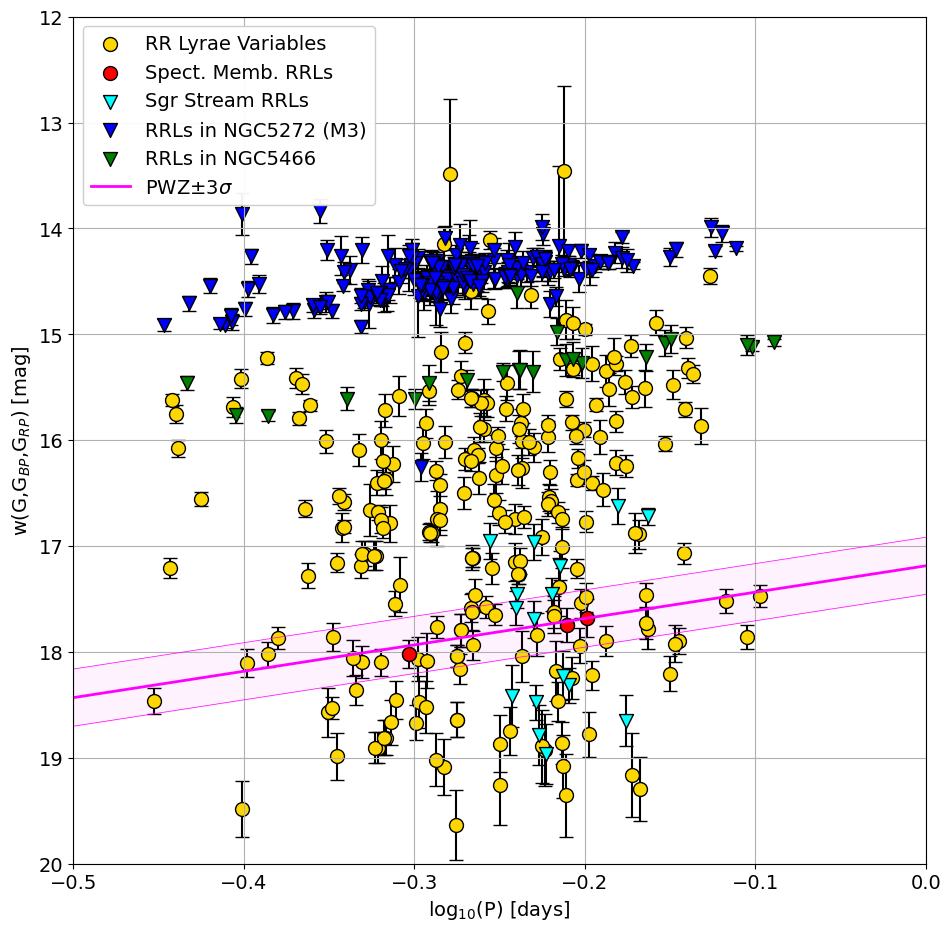

In [33]:
## PWZ

plt.figure(figsize=(11,11))
plt.xlim(-0.5,0)
plt.ylim(20,12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'log$_{10}$(P) [days]', fontsize=14)
plt.ylabel(r'w(G,G$_{BP}$,G$_{RP}$) [mag]', fontsize=14)


## All RR Lyrae

plt.scatter(np.log10(rr_final['pf']), w_mag_final, c='gold', edgecolor='k', marker='o', s=100, label='RR Lyrae Variables', zorder=1)
plt.scatter(np.log10(rr_final['p1_o'])+0.127, w_mag_final, c='gold', edgecolor='k', marker='o', s=100, zorder=1) # Fundamentalisation
plt.errorbar(np.log10(rr_final['pf']), w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(rr_final['p1_o'])+0.127, w_mag_final, yerr=w_mag_error_final, fmt='o', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(memb_rr['pf']), w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, label='Spect. Memb. RRLs', zorder=2)
plt.scatter(np.log10(memb_rr['p1_o'])+0.127, w_mag_memb_rr, color='red', edgecolor='k', marker='o', s=100, zorder=2)

plt.scatter(np.log10(data_sgr['pf']), w_mag_sgr, c='cyan', edgecolor='k', marker='v', s=100, label='Sgr Stream RRLs', zorder=3)
plt.scatter(np.log10(data_sgr['p1_o'])+0.127, w_mag_sgr, c='cyan', edgecolor='k', marker='v', s=100, zorder=3) # Fundamentalisation
plt.errorbar(np.log10(data_sgr['pf']), w_mag_sgr, yerr=w_mag_sgr_error, fmt='v', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(data_sgr['p1_o'])+0.127, w_mag_sgr, yerr=w_mag_sgr_error, fmt='v', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(data_ngc5272['pf']), w_mag_ngc5272, marker='v', color='blue', edgecolor='k', s=100, label='RRLs in NGC5272 (M3)')
plt.scatter(np.log10(data_ngc5272['p1_o'])+0.127, w_mag_ngc5272, marker='v', color='blue', edgecolor='k', s=100)
plt.errorbar(np.log10(data_ngc5272['pf']), w_mag_ngc5272, yerr=w_mag_ngc5272_error, fmt='v', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(data_ngc5272['p1_o'])+0.127, w_mag_ngc5272, yerr=w_mag_ngc5272_error, fmt='v', capsize=5, color='k', zorder=0)

plt.scatter(np.log10(data_ngc5466['pf']), w_mag_ngc5466, marker='v', color='green', edgecolor='k', s=100, label='RRLs in NGC5466')
plt.scatter(np.log10(data_ngc5466['p1_o'])+0.127, w_mag_ngc5466,marker='v', color='green', edgecolor='k', s=100)
plt.errorbar(np.log10(data_ngc5466['pf']), w_mag_ngc5466, yerr=w_mag_ngc5466_error, fmt='v', capsize=5, color='k', zorder=0)
plt.errorbar(np.log10(data_ngc5466['p1_o'])+0.127, w_mag_ngc5466, yerr=w_mag_ngc5466_error, fmt='v', capsize=5, color='k', zorder=0)

## Intrinsic dispersion

plt.plot(t, pw_generic, c='magenta', linewidth=2, label=r'PWZ$\pm 3 \sigma$', linestyle = 'solid')
plt.plot(t, pw_generic + 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.plot(t, pw_generic - 3*w_sigma, c='magenta', linewidth=0.5, linestyle = 'solid')
plt.fill_between(t, pw_generic + 3*w_sigma, pw_generic - 3*w_sigma, alpha=0.05, color='magenta', zorder=0)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_paper01.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


### Color-Magnitude Diagram

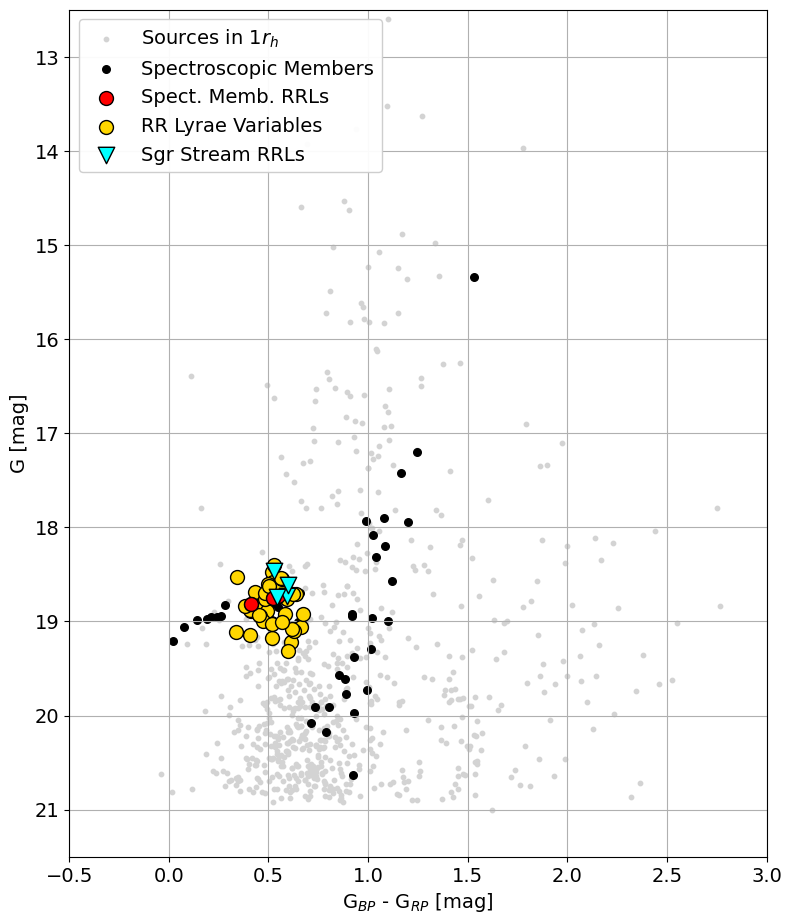

In [34]:
## CMD 

plt.figure(figsize=(9,11))
plt.xlim(-0.5,3)
plt.ylim(21.5,12.5)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel(r'G$_{BP}$ - G$_{RP}$ [mag]', fontsize=14)
plt.ylabel('G [mag]', fontsize=14)

plt.scatter(data_1rh_final['phot_bp_mean_mag'] - data_1rh_final['phot_rp_mean_mag'], data_1rh_final['phot_g_mean_mag'], s=10, c='lightgrey', marker='o', label=r'Sources in 1$r_h$', zorder=0)
plt.scatter(memb['phot_bp_mean_mag'] - memb['phot_rp_mean_mag'], memb['phot_g_mean_mag'], s=30, marker='o', color='k', label='Spectroscopic Members', zorder=1)
plt.scatter(memb_rr['phot_bp_mean_mag'] - memb_rr['phot_rp_mean_mag'], memb_rr['int_average_g'], s=100, marker='o', color='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['phot_bp_mean_mag'] - rr_pw_final['phot_rp_mean_mag'], rr_pw_final['int_average_g'], s=100, marker='o', edgecolor='k', color='gold', label=r'RR Lyrae Variables', zorder=2)
plt.scatter(sgr_pw['phot_bp_mean_mag'] - sgr_pw['phot_rp_mean_mag'], sgr_pw['int_average_g'], s=140, marker='v', edgecolor='k', color='cyan', label='Sgr Stream RRLs', zorder=4)

plt.legend(loc=2, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_paper02.png', bbox_inches='tight', pad_inches=0)
plt.show()

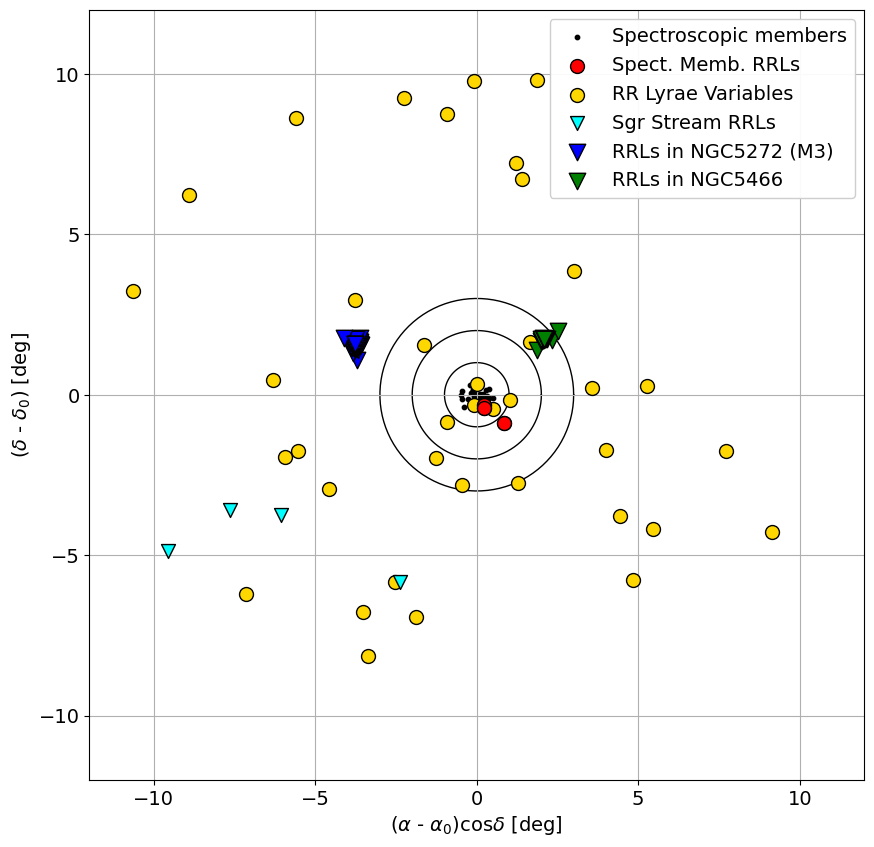

In [35]:
## Final map

t = np.linspace(0, 2*np.pi, 100)

plt.figure(figsize=(10,10))
plt.xlim(-12,12)
plt.ylim(-12,12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel(r'($\alpha$ - $\alpha_0$)cos$\delta$ [deg]', fontsize=14)
plt.ylabel(r'($\delta$ - $\delta_0$) [deg]', fontsize=14)

plt.scatter(memb['ra'] - center[0], memb['dec'] - center[1], s=10, marker='o', c='k', edgecolor='k', label='Spectroscopic members', zorder=1)
plt.scatter(memb_rr['ra'] - center[0], memb_rr['dec'] - center[1], s=100, marker='o', c='red', edgecolor='k', label='Spect. Memb. RRLs', zorder=3)
plt.scatter(rr_pw_final['ra']- center[0], rr_pw_final['dec']- center[1], s=100, marker='o', c='gold', edgecolor='k', label='RR Lyrae Variables', zorder=2)
plt.scatter(sgr_pw['ra'] - center[0], sgr_pw['dec'] - center[1], s=100, marker='v', color='cyan', edgecolor='k', label='Sgr Stream RRLs', zorder=4)
plt.scatter(data_ngc5272['ra'] - center[0], data_ngc5272['dec'] - center[1], s=140, marker='v', color='blue', edgecolor='k', label='RRLs in NGC5272 (M3)', zorder=2)
plt.scatter(data_ngc5466['ra'] - center[0], data_ngc5466['dec'] - center[1], s=140, marker='v', color='green', edgecolor='k', label='RRLs in NGC5466', zorder=2)

plt.plot(r_half*1*np.cos(t),r_half*1*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*2*np.cos(t),r_half*2*np.sin(t),c='k', linewidth=1, zorder=0)
plt.plot(r_half*3*np.cos(t),r_half*3*np.sin(t),c='k', linewidth=1, zorder=0)

plt.legend(loc=1, fontsize=14, framealpha=0.95)
plt.grid(True)
plt.savefig('Plot/BootesIII/BootesIII_final_map.png', bbox_inches='tight', pad_inches=0.1)
plt.show()

## File saving

In [36]:
# RR Lyrae in 3° after PM cut
#rr_final.to_csv('Output/BootesIII/BootesIII_rr_pm.csv', index=False)

# RR Lyrae in 3° after PM and PWZ cut
#rr_pw_final.to_csv('Output/BootesIII/BootesIII_rr_pm+pwz.csv', index=False)

# Final 45 RRLs in Bootes III
final = pd.concat([rr_pw_final, sgr_pw])
print('Final member RR Lyrae: ' + str(len(final)))
final.to_csv('Output/BootesIII/BootesIII_rr_final.csv', index=False)

Final member RR Lyrae: 45


## Conclusions
- After Proper Motion, PWZ, and Metallicity selections, we found 45 RRLs: 41 in vari_rrlyrae + 4 from Sgr Stream
- There are many RRd in Boötes III, only 2 survive the selections
- The Spectroscopic RRL member passes the PWZ selection
- We found 20 RRLs more than Tau 2024, but 7 of theirs are missinig